# Energy Injection Scenarios (PDE Solver)

PDE runs for three physically motivated injection histories:

1. **Decaying particles** --- exponential decay of a long-lived relic
2. **DM annihilation (s-wave)** --- $\langle\sigma v\rangle$ constant
3. **DM annihilation (p-wave)** --- $\langle\sigma v\rangle \propto v^2 \propto (1+z)$

The PDE handles continuous injection self-consistently; the distortion at each $z$ feeds back into DC/BR and $T_e$.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from spectroxide import (
    solve, mu_shape, y_shape, delta_n_to_delta_I, cosmic_time, apply_style,
)

apply_style()


## 1. Decaying particles

The decay rate $\Gamma_X$ [s$^{-1}$] is the input. To probe a target injection epoch $z_X$, set $\Gamma_X = 1/t(z_X)$ so that most decays happen near $z_X$. Different $z_X$ probe different regimes: $z_X > 10^5$ → $\mu$-type, $z_X \sim 5\times 10^4$ → mixed, $z_X < 10^4$ → $y$-type.


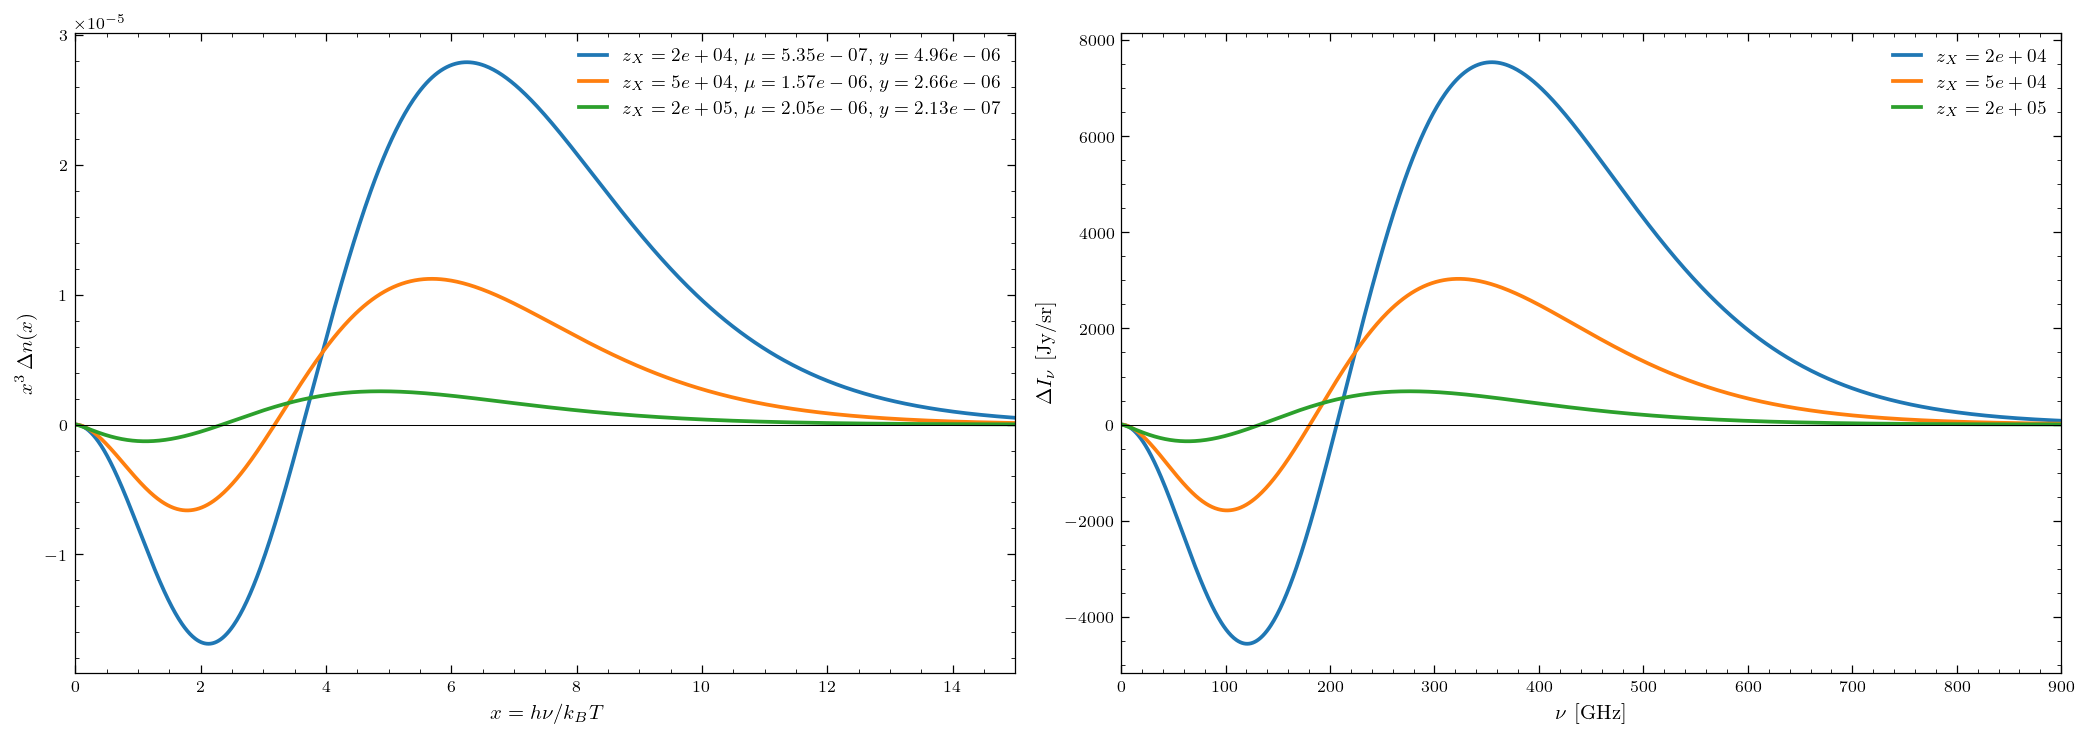

In [8]:
z_x_values = [2e4, 5e4, 2e5]
f_x = 5e5  # eV per baryon released

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for z_x in z_x_values:
    gamma_x = 1.0 / cosmic_time(z_x)  # Γ_X = 1/t(z_X)
    result = solve(
        injection={'type': 'decaying_particle', 'f_x': f_x, 'gamma_x': gamma_x},
        z_start=5e6, z_end=1e3,
    )
    nu_ghz, dI = delta_n_to_delta_I(result.x, result.delta_n)
    label = f'$z_X = {z_x:.0e}$, $\\mu={result.mu:.2e}$, $y={result.y:.2e}$'
    ax1.plot(result.x, result.x**3 * result.delta_n, lw=1.8, label=label)
    ax2.plot(nu_ghz, dI, lw=1.8, label=f'$z_X = {z_x:.0e}$')

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=9)
ax1.set(xlabel=r'$x = h\nu / k_B T$', ylabel=r'$x^3 \, \Delta n(x)$', xlim=(0, 15))
ax2.set(xlabel=r'$\nu$ [GHz]', ylabel=r'$\Delta I_\nu$ [Jy/sr]', xlim=(0, 900))
plt.tight_layout()
plt.show()


## 2. DM annihilation: s-wave vs p-wave

| | s-wave | p-wave |
|---|--------|--------|
| $\langle\sigma v\rangle$ | const | $\propto v^2 \propto (1+z)$ |
| Heating rate | $\propto (1+z)^3$ | $\propto (1+z)^4$ |
| Distortion | mixed $\mu + y$ | $\mu$-dominated |


In [9]:
res_s = solve(injection={'type': 'annihilating_dm', 'f_ann': 2e-23},
               z_start=5e6, z_end=1e3)
res_p = solve(injection={'type': 'annihilating_dm_pwave', 'f_ann': 2e-27},
               z_start=5e6, z_end=1e3)

for name, r in [('s-wave', res_s), ('p-wave', res_p)]:
    print(f'{name}: mu = {r.mu:.3e}, y = {r.y:.3e}, mu/y = {r.mu/r.y:.1f}')


s-wave: mu = 4.693e-10, y = 7.176e-11, mu/y = 6.5
p-wave: mu = 1.544e-07, y = 3.800e-09, mu/y = 40.6


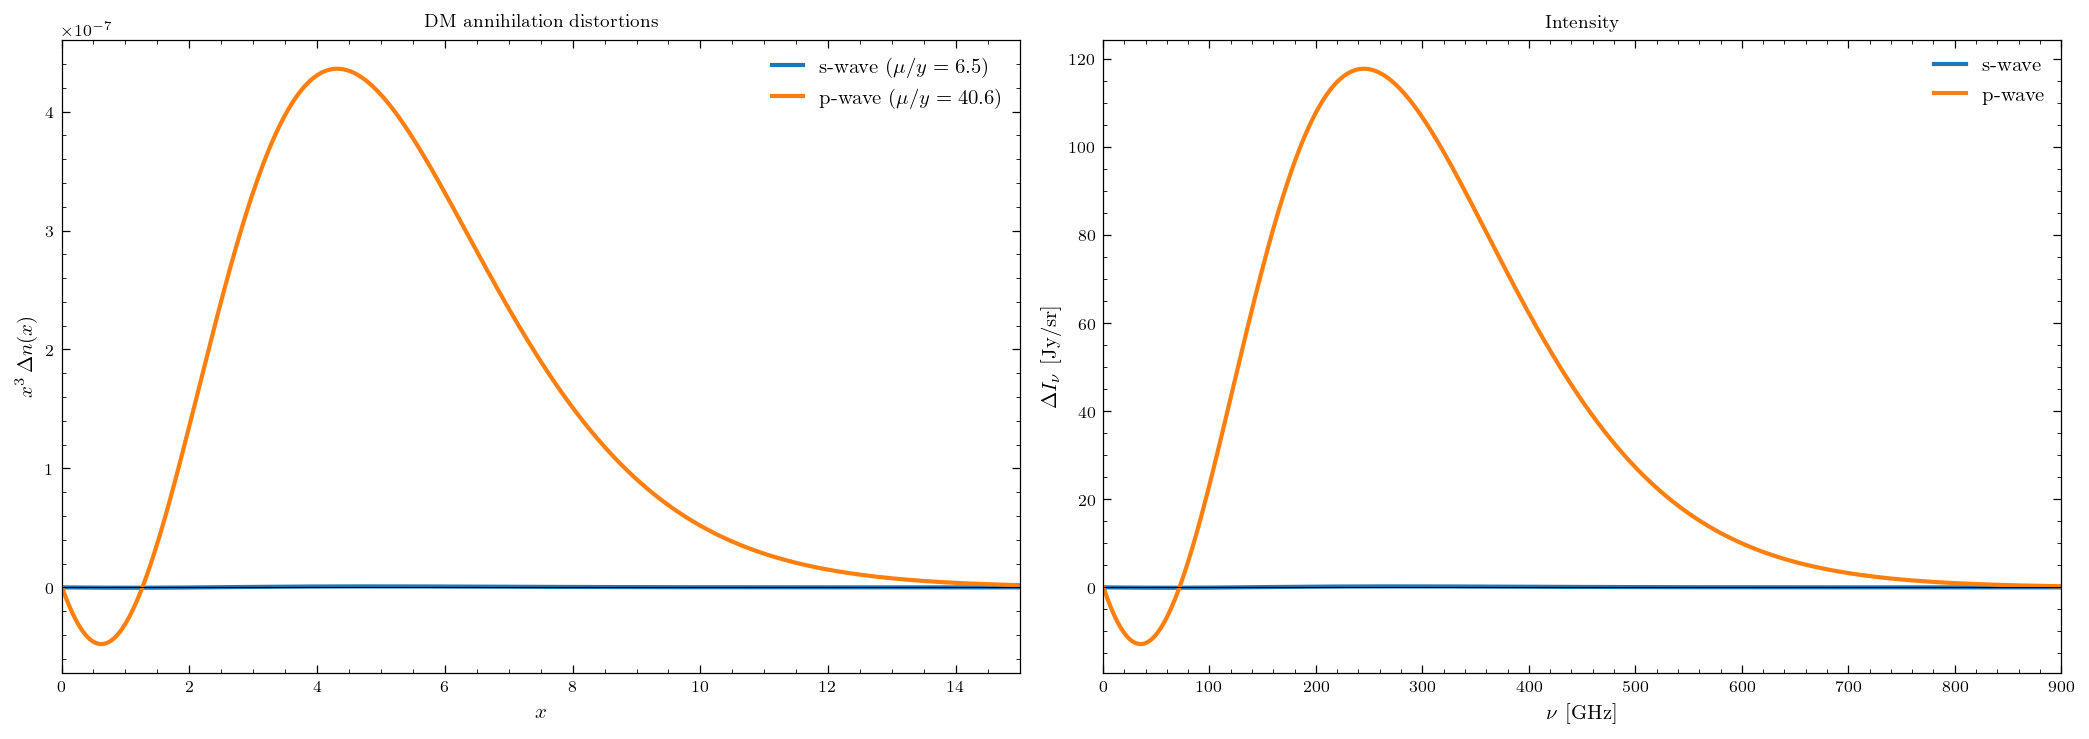

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for r, lab in [(res_s, 's-wave'), (res_p, 'p-wave')]:
    ax1.plot(r.x, r.x**3 * r.delta_n, lw=2,
             label=f'{lab} ($\\mu/y = {r.mu/r.y:.1f}$)')
    nu, dI = delta_n_to_delta_I(r.x, r.delta_n)
    ax2.plot(nu, dI, lw=2, label=lab)

for ax in (ax1, ax2):
    ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=10)
ax1.set(xlabel=r'$x$', ylabel=r'$x^3 \, \Delta n(x)$', xlim=(0, 15),
        title='DM annihilation distortions')
ax2.set(xlabel=r'$\nu$ [GHz]', ylabel=r'$\Delta I_\nu$ [Jy/sr]', xlim=(0, 900),
        title='Intensity')
plt.tight_layout()
plt.show()


## Summary

| Scenario | injection dict |
|---|---|
| Decaying particle | `{'type': 'decaying_particle', 'f_x': ..., 'gamma_x': ...}` |
| s-wave DM | `{'type': 'annihilating_dm', 'f_ann': ...}` |
| p-wave DM | `{'type': 'annihilating_dm_pwave', 'f_ann': ...}` |

s-wave gives mixed $\mu+y$; p-wave is nearly pure $\mu$. Decay lifetime sets injection epoch.

**Next:** `03_new_physics.ipynb` — dark photon oscillation, monochromatic photon injection.
